In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns ; sns.set()

%matplotlib inline

df = pd.read_csv('csv_files/cleaned_list.csv')
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,same_state,company_age,num_competitors,job_tag,job_level,State,Region,Division,Latitude,Longitude
0,Data Scientist,70-116,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,0,52,0,data scientist,none,Virginia,South,South Atlantic,38.003386,-79.458786
1,Data Scientist,70-116,"VA Boston Healthcare System\nBoston, Massachus...",3.6,VA Boston Healthcare System,"Boston, MA","Boston, MA",201 to 500 employees,-1,Hospital,...,1,-1,0,data scientist,none,Massachusetts,Northeast,New England,42.062940,-71.718067
2,Data & Analytics Consultant,70-116,WHO WE LOOK FOR\n\nAn SEI Consultant is a mast...,4.6,SEI,"Cincinnati, OH","Cincinnati, OH",201 to 500 employees,1992,Company - Private,...,1,28,0,other,none,Ohio,Midwest,East North Central,40.190362,-82.669252
3,R&D Scientist,70-116,"Since 2001, Hygiena has been on a mission to b...",3.9,Hygiena,"New Castle, DE","Camarillo, CA",201 to 500 employees,-1,Company - Private,...,0,-1,2,other,none,Delaware,South,South Atlantic,39.145251,-75.418921
4,Data Scientist,70-116,Why We Work at Dun & Bradstreet\n\n\nWe are at...,3.1,Dun & Bradstreet,"Austin, TX","Short Hills, NJ",1001 to 5000 employees,1841,Company - Private,...,0,179,2,data scientist,none,Texas,South,West South Central,31.169336,-100.076842


In [2]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'min_salary', 'max_salary', 'avg_salary', 'city', 'state',
       'same_state', 'company_age', 'num_competitors', 'job_tag', 'job_level',
       'State', 'Region', 'Division', 'Latitude', 'Longitude'],
      dtype='str')

In [3]:
# interested categories 

cat = ['job_tag', 'job_level', 'state', 'Size', 'Industry', 'Sector', 'Type of ownership', 'Rating', 'Revenue', 'avg_salary', 'same_state', 'Founded', 'company_age', 'num_competitors', 'Region', 'Division']


model_df = df[cat]
print(model_df.shape)
model_df.head()

(299, 16)


,job_tag,job_level,state,Size,Industry,Sector,Type of ownership,Rating,Revenue,avg_salary,same_state,Founded,company_age,num_competitors,Region,Division
0,data scientist,none,VA,5001 to 10000 employees,Research & Development,Business Services,Company - Public,4.2,$1 to $2 billion (USD),93.0,0,1968,52,0,South,South Atlantic
1,data scientist,none,MA,201 to 500 employees,Health Care Services & Hospitals,Health Care,Hospital,3.6,Unknown / Non-Applicable,93.0,1,-1,-1,0,Northeast,New England
2,other,none,OH,201 to 500 employees,Consulting,Business Services,Company - Private,4.6,$50 to $100 million (USD),93.0,1,1992,28,0,Midwest,East North Central
3,other,none,DE,201 to 500 employees,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,Company - Private,3.9,$100 to $500 million (USD),93.0,0,-1,-1,2,South,South Atlantic
4,data scientist,none,TX,1001 to 5000 employees,IT Services,Information Technology,Company - Private,3.1,$1 to $2 billion (USD),93.0,0,1841,179,2,South,West South Central


In [4]:
per_missing = (round((model_df.isna().sum()/model_df.shape[0]) * 100,2).to_frame(name = '% of missing values'))

print(per_missing)
for index, row in per_missing.iterrows():
    if row.iloc[0] > 50:
#         print('yes')
        model_df.drop(labels=index, inplace=True, axis=1)
    else:
#         pass
        model_df.fillna('Unknown', inplace=True)
    
model_df.isna().sum()

                   % of missing values
job_tag                           0.00
job_level                         0.00
state                             4.35
Size                              0.00
Industry                          0.00
Sector                            0.00
Type of ownership                 0.00
Rating                            0.00
Revenue                           0.00
avg_salary                        0.00
same_state                        0.00
Founded                           0.00
company_age                       0.00
num_competitors                   0.00
Region                            5.02
Division                          5.02


job_tag              0
job_level            0
state                0
Size                 0
Industry             0
Sector               0
Type of ownership    0
Rating               0
Revenue              0
avg_salary           0
same_state           0
Founded              0
company_age          0
num_competitors      0
Region               0
Division             0
dtype: int64

In [5]:
model_df.Region.unique()

<StringArray>
['South', 'Northeast', 'Midwest', 'West', 'Unknown']
Length: 5, dtype: str

In [6]:
# linearregression
# decision tree
# Random Forrest


from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error 


In [7]:
# getting dummie variables and spliting dataset

model_df_dum = pd.get_dummies(model_df)
X = model_df_dum.drop('avg_salary', axis = 1)
y = model_df_dum['avg_salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)


In [8]:
# initilize models to be used 
lr = LinearRegression()
ls = Lasso()
rf = RandomForestRegressor()
dt = DecisionTreeRegressor()

models = [lr, ls, rf, dt]
model_names = ['Linear', 'Lasso', 'Rand.F', 'Dec.T']


ML Model:  LinearRegression() Avg. Cross Val score:  -28.01767354541616 Mean Absolute Error: 30.232764160607125


ML Model:  Lasso(alpha=0.44) Avg. Cross Val score:  -19.424819022742643 Mean Absolute Error: 21.338550431517525


ML Model:  RandomForestRegressor() Avg. Cross Val score:  -20.187727340067333 Mean Absolute Error: 21.723953253968258
ML Model:  DecisionTreeRegressor() Avg. Cross Val score:  -24.823813131313134 Mean Absolute Error: 26.227777777777778


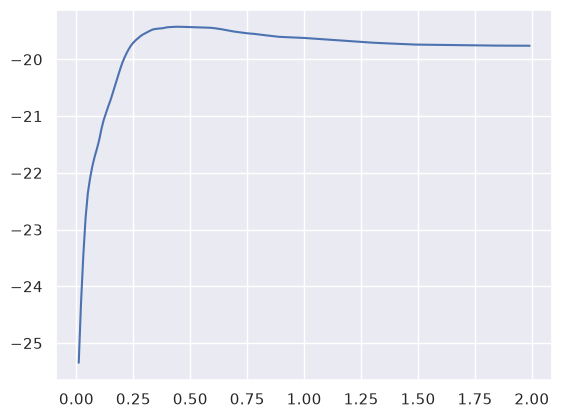

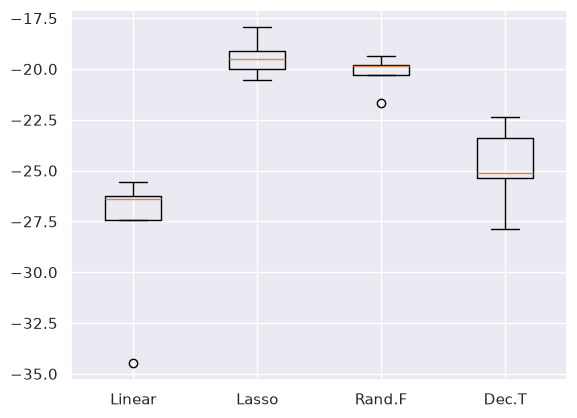

In [9]:
# looping through our models

error_results =[]
model_predictions = []

ls_alpha = []
ls_error = []
for model_name, model in zip(model_names,models):
    if model_name != 'Lasso':
        cv_error = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
        error_results.append((cv_error))  # appending to our results the avg score from our cross val

    #     cv_pred = cross_val_predict(model, X_train, y_train, cv=5)
    #     model_predictions.append(cv_pred)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        model_predictions.append(pred)

        mse = mean_absolute_error(y_test, pred)

        print('ML Model: ', model, 'Avg. Cross Val score: ', cv_error.mean(), 'Mean Absolute Error:', mse)
    elif model_name == 'Lasso':
        # since lasso is based on alpha we have to optimize for that
        for i in range(1,200):
            ls_alpha.append(i/100)
            temp_model = Lasso(alpha=(i/100))
            ls_error.append(np.mean(cross_val_score(temp_model, X_train, y_train, scoring='neg_mean_absolute_error', cv=5)))
            
        df_error = pd.DataFrame(tuple(zip(ls_alpha,ls_error)), columns=['alpha', 'error'])
        opt_alpha = float(df_error.loc[df_error['error'].idxmax(), 'alpha'])  # scalar, not array (sklearn>=1.2 is strict)
        model = Lasso(alpha = opt_alpha)
            
        cv_error = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
        error_results.append((cv_error))
            
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        model_predictions.append(pred)

        mse = mean_absolute_error(y_test, pred)
    
        print('ML Model: ', model, 'Avg. Cross Val score: ', cv_error.mean(), 'Mean Absolute Error:', mse)
            
        plt.plot(ls_alpha, ls_error)
    
fig, ax = plt.subplots()
plt.boxplot(error_results)
ax.set_xticklabels(model_names)
plt.show()

In [10]:
# grid search to optimize parameters
from sklearn.model_selection import GridSearchCV

parameters = {'n_estimators': range(10, 300, 10), 'criterion': ('squared_error', 'absolute_error'), 'max_features': ('sqrt', 'log2')}  # updated: 'mse'/'mae'/'auto' removed in sklearn>=1.2
gs = GridSearchCV(rf,parameters,scoring='neg_mean_absolute_error',cv=3)
gs.fit(X_train,y_train)

gs.best_score_


np.float64(-19.283163663663668)

In [11]:
gs.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'absolute_error'
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the n

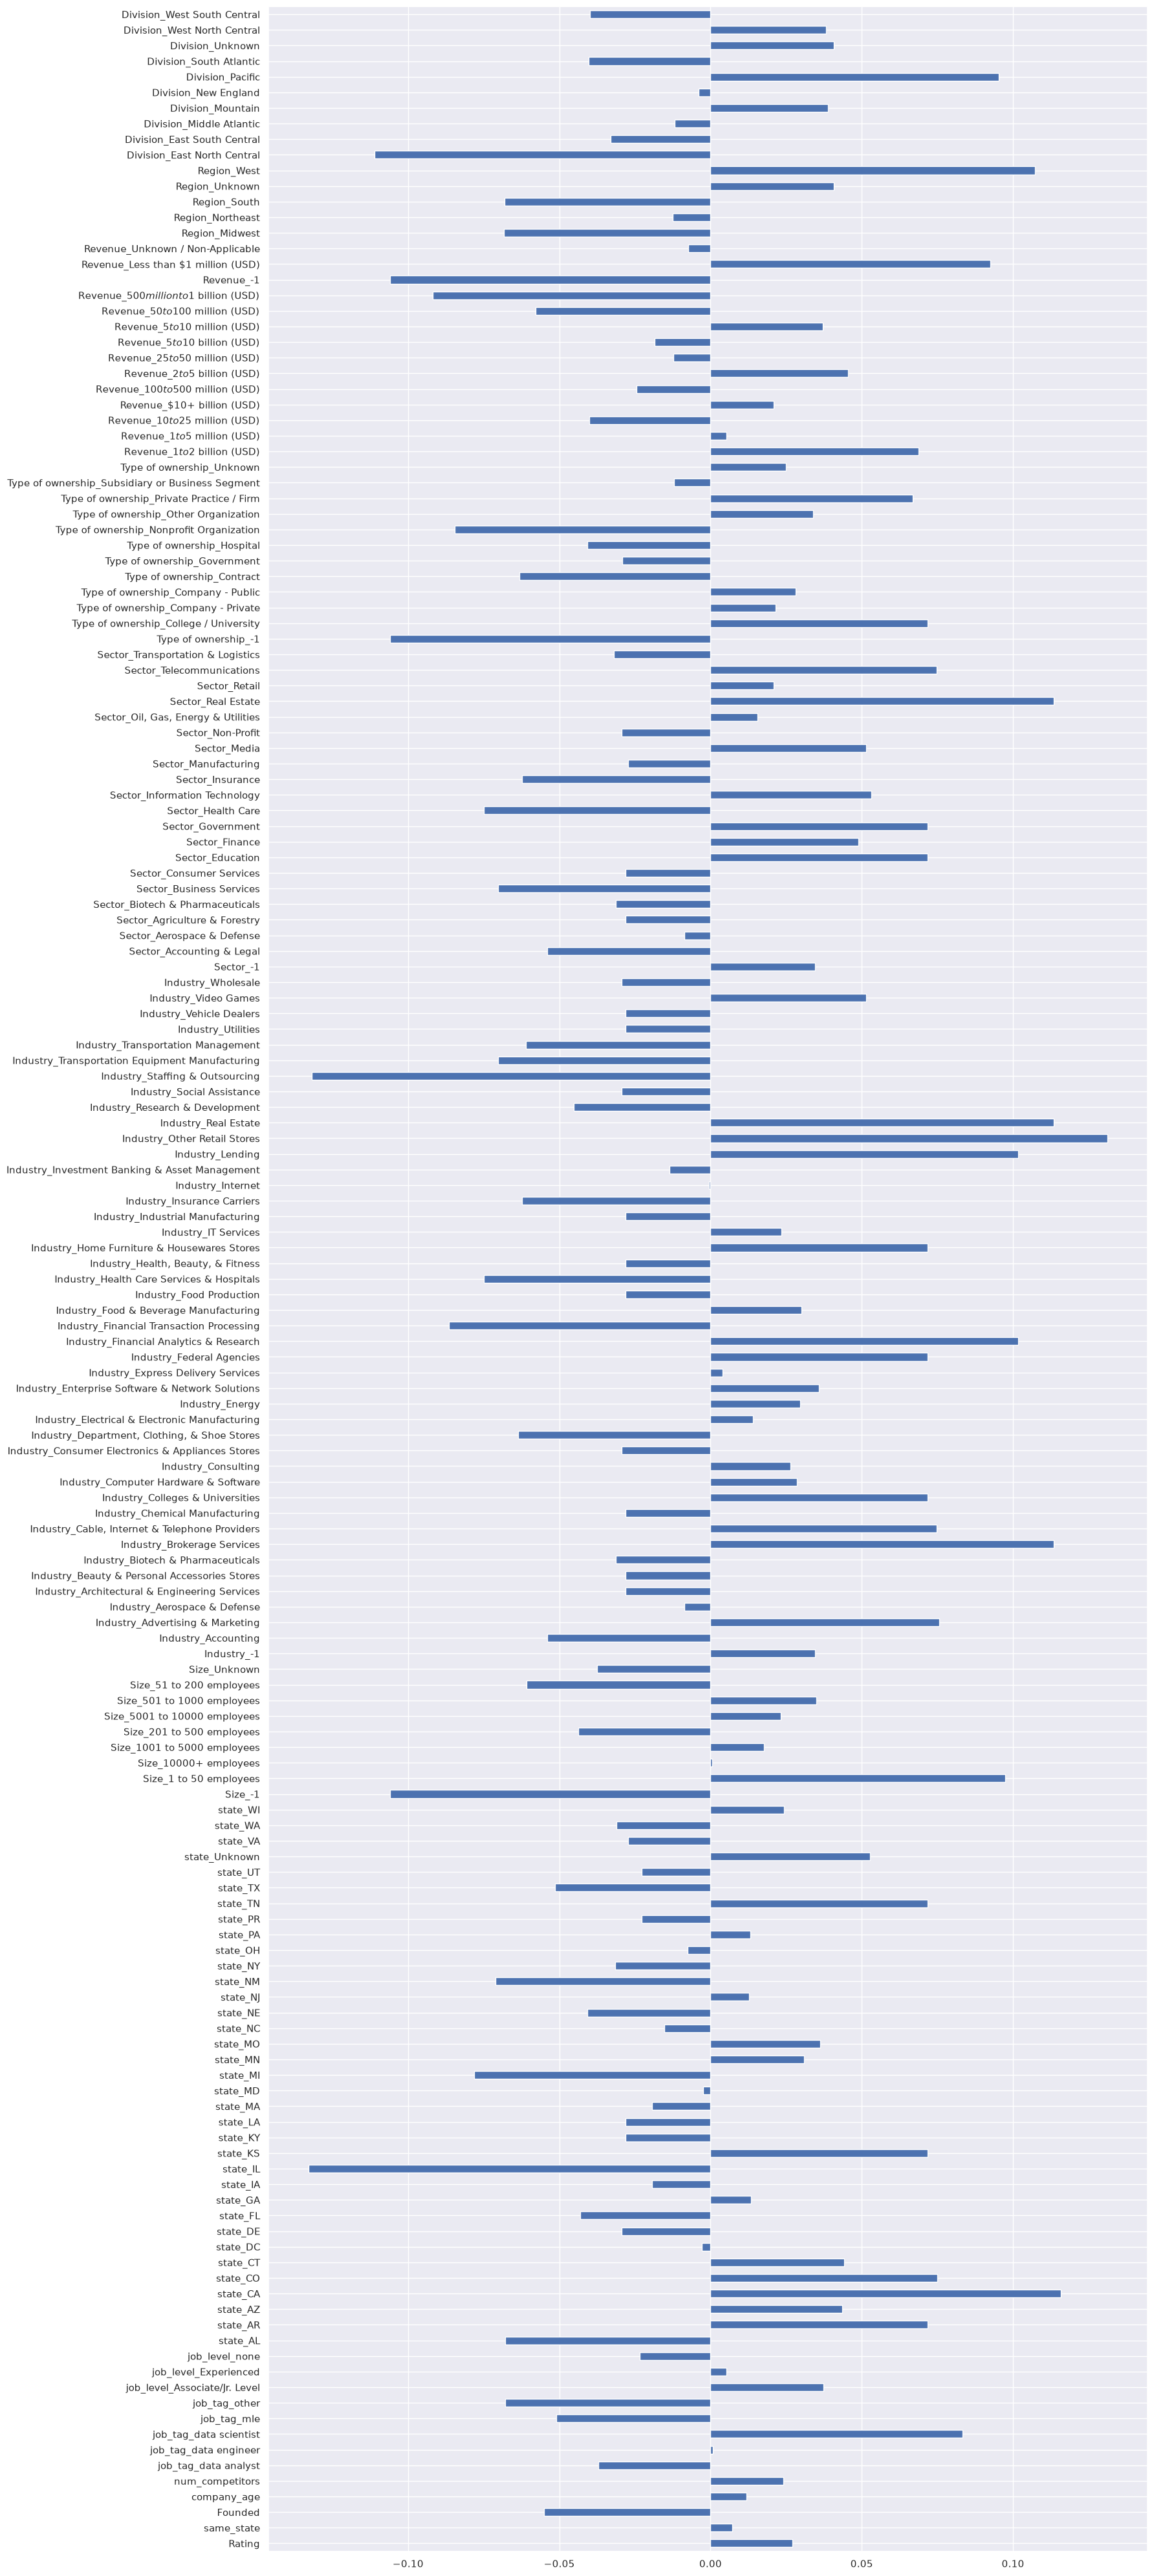

In [12]:
# we can see some of the correlations to average salary based and compare and also look atht the summary statistics from the model 

corr_with = X.corrwith(model_df_dum.avg_salary)  # here were checking correlations of our feature variables with our target y

fig, ax = plt.subplots(figsize=(18,40))
corr_with.plot(kind='barh', ax=ax)
plt.tight_layout()